In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
data = ["/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_customers_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_products_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/product_category_name_translation.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_orders_dataset.csv",
"/kaggle/input/datasets/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv"]

In [3]:

customers = pd.read_csv(data[0])
sellers = pd.read_csv(data[1])
order_reviews = pd.read_csv(data[2])
order_items = pd.read_csv(data[3])
products = pd.read_csv(data[4])
geolocation = pd.read_csv(data[5])
category_translation = pd.read_csv(data[6])
orders = pd.read_csv(data[7])
order_payments = pd.read_csv(data[8])

# Customer table (99441, 5)
* grain - "customer info"
* columns
  - customer_id (primary key)
  - customer_unique_id (have duplicates) - could mean repeating customers
  - customer_city and customer_state

In [4]:
customers.shape

(99441, 5)

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
print(customers.customer_unique_id.nunique())
customers.customer_id.nunique()

96096


99441

# Seller Table (3095, 4)
* grain - seller detail
* columns:
  - seller_id (primary key)
  - seller_city and seller_state

In [9]:
sellers.shape

(3095, 4)

In [10]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [11]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [12]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

# Order_reviews (99224, 7)
* grain - 1 row contains info of review given to a order
* columns:
  - review_id and order_id both has duplicates
    - many reviews could be given to single order and multiple order might've recieved same review
    - not all orders have recieved reviews
  - review_score

In [13]:
order_reviews.shape

(99224, 7)

In [14]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [15]:
order_reviews.review_id.duplicated().value_counts()

review_id
False    98410
True       814
Name: count, dtype: int64

In [16]:
order_reviews.order_id.duplicated().value_counts()

order_id
False    98673
True       551
Name: count, dtype: int64

# Order_Items (112650, 7)
* grain - item per order (order_id + order_item_id) - key
* column:
  - order_id, order_item_id(sequential - order number for product per order)
  - product_id, seller_id, price

In [17]:
order_items.shape

(112650, 7)

In [18]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [19]:
order_items.head(20)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [20]:
order_items.order_item_id.value_counts()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [21]:
order_items.product_id.value_counts()

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
                                   ... 
038c0dd7c1e48a1588f8919a0c305727      1
aa20709d44e96059764f1b0386d3bcfa      1
9ae3dacfd2327107a1e28274fac25a4e      1
0c398b245c9b74ef2bf4343b6fe73237      1
446295cf6f689d4db477145815362608      1
Name: count, Length: 32951, dtype: int64

In [22]:
order_items.order_id.value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
5a082b558a3798d3e36d93bfa8ca1eae     1
5a07264682e0b8fbb3f166edbbffc6e8     1
5a071192a28951b76774e5a760c8c9b7     1
5a06fc966a12b41bf401b344464fd4b1     1
5a0e5ad33542c79b10be87a344ee0086     1
Name: count, Length: 98666, dtype: int64

In [23]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


# Products (32951, 9)
* grain - 1 product per row, product_id - primary key
* columns - product_id, product_category_name

In [24]:
products.shape

(32951, 9)

In [25]:
products.info

<bound method DataFrame.info of                              product_id              product_category_name  \
0      1e9e8ef04dbcff4541ed26657ea517e5                         perfumaria   
1      3aa071139cb16b67ca9e5dea641aaa2f                              artes   
2      96bd76ec8810374ed1b65e291975717f                      esporte_lazer   
3      cef67bcfe19066a932b7673e239eb23d                              bebes   
4      9dc1a7de274444849c219cff195d0b71              utilidades_domesticas   
...                                 ...                                ...   
32946  a0b7d5a992ccda646f2d34e418fff5a0                   moveis_decoracao   
32947  bf4538d88321d0fd4412a93c974510e6  construcao_ferramentas_iluminacao   
32948  9a7c6041fa9592d9d9ef6cfe62a71f8c                    cama_mesa_banho   
32949  83808703fc0706a22e264b9d75f04a2e             informatica_acessorios   
32950  106392145fca363410d287a815be6de4                    cama_mesa_banho   

       product_name_lenght  pro

In [26]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
products.product_category_name.value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

# category translation (71, 2)
* grain - brazillian to english translation for product category
* columns -
  - product_category_name , product_category_name_english

In [28]:
category_translation.shape

(71, 2)

In [29]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# orders (99441, 8)
* grain - order_id -> primary key
* columns: 
  - order_id, customer_id, order_status

In [30]:
orders.shape

(99441, 8)

In [31]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [32]:
orders.order_id.duplicated().value_counts()

order_id
False    99441
Name: count, dtype: int64

In [33]:
orders.customer_id.duplicated().value_counts()

customer_id
False    99441
Name: count, dtype: int64

In [34]:
(customers.duplicated()).sum()

np.int64(0)

In [35]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [36]:
orders.customer_id.duplicated().sum()

np.int64(0)

In [37]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [38]:
orders.order_status.value_counts().sort_values()

order_status
approved           2
created            5
processing       301
invoiced         314
unavailable      609
canceled         625
shipped         1107
delivered      96478
Name: count, dtype: int64

In [39]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [40]:
orders.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [41]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [42]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [43]:
sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

In [44]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [45]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [46]:
orders.merge(customers,right_on = 'customer_id', left_on = "customer_id", how = 'left').order_id.duplicated().sum()

np.int64(0)

In [47]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [48]:
customers.customer_id.count()

np.int64(99441)

In [49]:
duplicated_cust_un_id = customers[customers.customer_unique_id.duplicated(keep = False)]
duplicated_cust_un_id.customer_unique_id.value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
35e146c985a9cf989c91edb4c0c156fa     2
5cc1eb5a94ab59494d63f06a5c7eec15     2
bc877a9f97bb3f3d4fcd5f86028f81a9     2
f7b981e8a280e455ac3cbe0d5d171bd1     2
c658495c41a24ef33a852db6840738a1     2
Name: count, Length: 2997, dtype: int64

In [50]:

duplicated_cust_un_id[customers.customer_unique_id == 'ca77025e7201e3b30c44b472ff346268']

/tmp/ipykernel_16/2230393080.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicated_cust_un_id[customers.customer_unique_id == 'ca77025e7201e3b30c44b472ff346268']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
26365,dc7dc47999d1b3c4c2f6a085a1a76eef,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
26809,6ccedfba5919d72fcc8c51bfa982de62,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
35408,c59e684f832f832056ceee2c310cfc7f,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
44672,852e5ea6e9d74416ddf88bdbdb3189b9,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
56584,71f39c371308d132d7633895477dd307,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
62252,b145bff18e79ac4dfb3fb91e61906f38,ca77025e7201e3b30c44b472ff346268,51021,recife,PE
68114,fc709ab645b71acd6046aeb03b590aa5,ca77025e7201e3b30c44b472ff346268,51021,recife,PE


In [51]:
orders[orders.customer_id == '6ccedfba5919d72fcc8c51bfa982de62']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
10135,8dacd1da7c4dc40d5c59e7ddd93b3ac8,6ccedfba5919d72fcc8c51bfa982de62,delivered,2018-06-01 11:38:29,2018-06-02 03:31:41,2018-06-04 14:37:00,2018-06-12 22:34:44,2018-07-18 00:00:00


In [52]:
orders[orders.customer_id == '852e5ea6e9d74416ddf88bdbdb3189b9']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
27521,cc9782f02aae34f01d12f3dbee4d5d93,852e5ea6e9d74416ddf88bdbdb3189b9,delivered,2018-05-03 06:11:22,2018-05-03 06:32:14,2018-05-04 12:50:00,2018-05-12 17:58:30,2018-06-04 00:00:00


In [53]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [54]:
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [55]:
cancelled_order = orders[orders.order_status == 'canceled']
cancelled_order[cancelled_order.isnull().any(axis = 1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


In [56]:
duplicated_order_id_in_payments = order_payments[order_payments.order_id.duplicated(keep = False)]
duplicated_order_id_in_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
25,5cfd514482e22bc992e7693f0e3e8df7,2,voucher,1,45.17
35,b2bb080b6bc860118a246fd9b6fad6da,1,credit_card,1,173.84
75,3689194c14ad4e2e7361ebd1df0e77b0,2,voucher,1,57.53
84,723e462ce1ee50e024887c0b403130f3,1,credit_card,1,13.80
102,21b8b46679ea6482cbf911d960490048,2,voucher,1,43.12
...,...,...,...,...,...
103778,fd86c80924b4be8fb7f58c4ecc680dae,1,credit_card,1,76.10
103817,6d4616de4341417e17978fe57aec1c46,1,credit_card,1,19.18
103860,31bc09fdbd701a7a4f9b55b5955b8687,6,voucher,1,77.99
103869,c9b01bef18eb84888f0fd071b8413b38,1,credit_card,6,238.16


In [57]:
orders[orders.order_id == '31bc09fdbd701a7a4f9b55b5955b8687']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
54266,31bc09fdbd701a7a4f9b55b5955b8687,106a2d44b8756af49c5c3299fb8001f1,delivered,2017-10-14 00:19:16,2017-10-15 01:14:32,2017-10-17 13:08:09,2017-10-21 14:42:01,2017-11-06 00:00:00


In [58]:
duplicated_order_id_in_payments[duplicated_order_id_in_payments.order_id == '31bc09fdbd701a7a4f9b55b5955b8687'].sort_values(by = 'payment_sequential')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
45492,31bc09fdbd701a7a4f9b55b5955b8687,1,voucher,1,26.86
82459,31bc09fdbd701a7a4f9b55b5955b8687,2,voucher,1,55.71
27995,31bc09fdbd701a7a4f9b55b5955b8687,3,voucher,1,37.88
43160,31bc09fdbd701a7a4f9b55b5955b8687,4,voucher,1,40.33
74317,31bc09fdbd701a7a4f9b55b5955b8687,5,voucher,1,22.28
103860,31bc09fdbd701a7a4f9b55b5955b8687,6,voucher,1,77.99
39416,31bc09fdbd701a7a4f9b55b5955b8687,7,voucher,1,3.48


```
weekly or monthly?
what period?
which order statuses count?
which date defines the period?
how revenue should be calculated?
whether to look at absolute values, percentage change, or both?

| Period | Revenue | Orders | AOV |
| ------ | ------: | -----: | --: |
| ...    |     ... |    ... | ... |


In [59]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [60]:
completed_orders = orders[orders.order_status == 'delivered']
completed_orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00
10,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00


In [61]:
order_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [62]:
order_payments.shape

(103886, 5)

In [63]:
order_payment_agg = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
order_payment_agg

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


In [64]:
order_payments_agg_merged = completed_orders.merge(order_payment_agg, on = 'order_id', how = 'inner')
order_payments_agg_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62


In [65]:
order_payments_agg_merged['order_delivered_customer_date'] = pd.to_datetime(order_payments_agg_merged['order_delivered_customer_date'])

In [66]:
order_payments_agg_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96477 entries, 0 to 96476
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96477 non-null  object        
 1   customer_id                    96477 non-null  object        
 2   order_status                   96477 non-null  object        
 3   order_purchase_timestamp       96477 non-null  object        
 4   order_approved_at              96463 non-null  object        
 5   order_delivered_carrier_date   96475 non-null  object        
 6   order_delivered_customer_date  96469 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96477 non-null  object        
 8   payment_value                  96477 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 6.6+ MB


In [67]:
order_payments_agg_merged['month'] = order_payments_agg_merged.order_delivered_customer_date.dt.month_name().str[:3]

In [68]:
order_payments_agg_merged['year'] = order_payments_agg_merged.order_delivered_customer_date.dt.year

In [69]:
order_payments_agg_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,month,year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,Oct,2017.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,Aug,2018.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,Aug,2018.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,Dec,2017.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,Feb,2018.0


In [70]:
delivered_order_payments_agg_merged = order_payments_agg_merged.drop(columns = ['order_purchase_timestamp','customer_id','order_status','order_delivered_customer_date','order_approved_at','order_delivered_carrier_date','order_estimated_delivery_date'])

In [71]:
delivered_order_payments_agg_merged.head(20)

,order_id,payment_value,month,year
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,Oct,2017.0
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,Aug,2018.0
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,Aug,2018.0
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,Dec,2017.0
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,Feb,2018.0
5,a4591c265e18cb1dcee52889e2d8acc3,175.26,Jul,2017.0
6,6514b8ad8028c9f2cc2374ded245783f,75.16,May,2017.0
7,76c6e866289321a7c93b82b54852dc33,35.95,Feb,2017.0
8,e69bfb5eb88e0ed6a785585b27e16dbf,169.76,Aug,2017.0
9,e6ce16cb79ec1d90b1da9085a6118aeb,259.06,May,2017.0


In [72]:
or_rev_aov = delivered_order_payments_agg_merged.groupby(['year','month']).agg(orders = ('order_id','count'),revenue = ('payment_value','sum'),aov = ('payment_value','mean')).reset_index()
or_rev_aov

,year,month,orders,revenue,aov
0,2016.0,Dec,4,960.85,240.212500
1,2016.0,Nov,57,11187.07,196.264386
2,2016.0,Oct,205,34438.41,167.992244
3,2017.0,Apr,1849,307722.84,166.426631
4,2017.0,Aug,4302,627367.19,145.831518
5,2017.0,Dec,7205,1102232.62,152.981627
6,2017.0,Feb,1351,228152.25,168.876573
7,2017.0,Jan,283,38708.63,136.779611
8,2017.0,Jul,3455,531271.71,153.768946
9,2017.0,Jun,3223,502197.97,155.816931


In [73]:
# 1. Define the correct chronological order of the months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 2. Convert the 'month' column to an ordered Categorical type
or_rev_aov['month'] = pd.Categorical(or_rev_aov['month'], categories=month_order, ordered=True)

# 3. Sort by 'year' first, then by 'month'
or_rev_aov_sorted = or_rev_aov.sort_values(by=['year', 'month']).reset_index(drop=True)

or_rev_aov_sorted


,year,month,orders,revenue,aov
0,2016.0,Oct,205,34438.41,167.992244
1,2016.0,Nov,57,11187.07,196.264386
2,2016.0,Dec,4,960.85,240.212500
3,2017.0,Jan,283,38708.63,136.779611
4,2017.0,Feb,1351,228152.25,168.876573
5,2017.0,Mar,2382,387275.32,162.584097
6,2017.0,Apr,1849,307722.84,166.426631
7,2017.0,May,3751,600917.76,160.202015
8,2017.0,Jun,3223,502197.97,155.816931
9,2017.0,Jul,3455,531271.71,153.768946


In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [75]:
or_rev_aov_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   year     25 non-null     float64 
 1   month    25 non-null     category
 2   orders   25 non-null     int64   
 3   revenue  25 non-null     float64 
 4   aov      25 non-null     float64 
dtypes: category(1), float64(3), int64(1)
memory usage: 1.3 KB


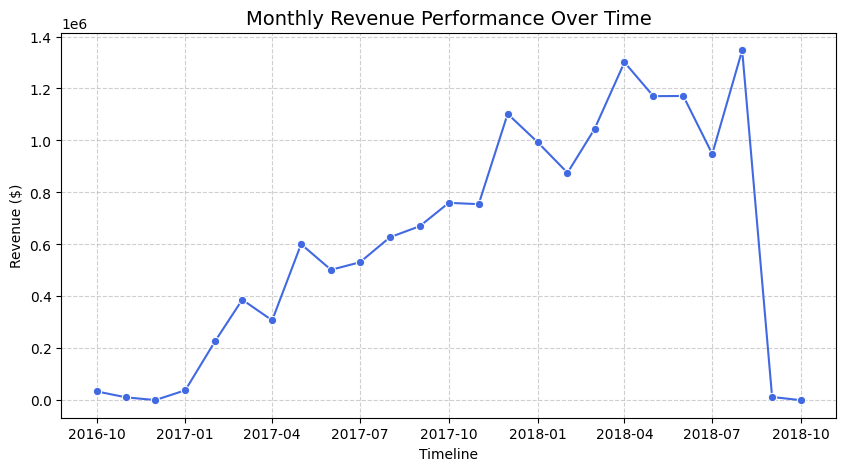

In [76]:
# 1. Combine year and month into a unified datetime column
or_rev_aov_sorted['date'] = pd.to_datetime(or_rev_aov_sorted['year'].astype(int).astype(str) + '-' + or_rev_aov_sorted['month'].astype(str), format='%Y-%b')

# 2. Plot the continuous trend line
plt.figure(figsize=(10, 5))
sns.lineplot(data=or_rev_aov_sorted, x='date', y='revenue', marker='o', color='royalblue')

plt.title('Monthly Revenue Performance Over Time', fontsize=14)
plt.xlabel('Timeline')
plt.ylabel('Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

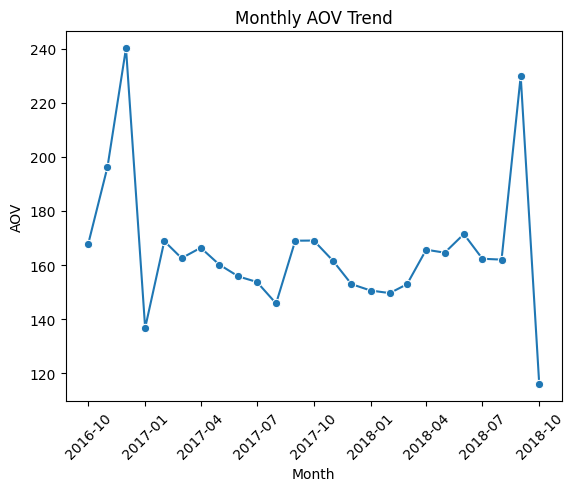

In [77]:
sns.lineplot(
    data=or_rev_aov_sorted,
    x='date',
    y='aov',
    marker='o'
)

plt.title('Monthly AOV Trend')
plt.xlabel('Month')
plt.ylabel('AOV')
plt.xticks(rotation=45)
plt.show()

In [78]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [79]:
orders.order_delivered_customer_date = pd.to_datetime(orders.order_delivered_customer_date)

In [80]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  object        
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [81]:
orders[(orders.order_delivered_customer_date.dt.year == 2018) & (orders.order_delivered_customer_date.dt.month == 10)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
18731,7e708aed151d6a8601ce8f2eaa712bf4,033fab69968b0d69099d64423831a236,delivered,2018-06-02 18:37:14,2018-06-02 18:51:31,2018-06-04 13:42:00,2018-10-17 13:22:46,2018-07-13 00:00:00
56635,450cb96c63e1e5b49d34f223f67976d2,27ae7c8a8fc20ce80d96f01b6f19961b,delivered,2018-05-21 06:48:46,2018-05-21 06:57:03,2018-06-01 13:14:00,2018-10-11 16:41:14,2018-06-27 00:00:00
92319,b2997e1d7061605e9285496c581d1fbd,9e83d47684eb1a58b1c31830f5de10ac,delivered,2018-07-30 09:08:06,2018-07-30 09:44:33,2018-07-31 12:50:00,2018-10-02 00:18:50,2018-08-14 00:00:00


In [82]:
or_rev_aov_sorted

,year,month,orders,revenue,aov,date
0,2016.0,Oct,205,34438.41,167.992244,2016-10-01
1,2016.0,Nov,57,11187.07,196.264386,2016-11-01
2,2016.0,Dec,4,960.85,240.212500,2016-12-01
3,2017.0,Jan,283,38708.63,136.779611,2017-01-01
4,2017.0,Feb,1351,228152.25,168.876573,2017-02-01
5,2017.0,Mar,2382,387275.32,162.584097,2017-03-01
6,2017.0,Apr,1849,307722.84,166.426631,2017-04-01
7,2017.0,May,3751,600917.76,160.202015,2017-05-01
8,2017.0,Jun,3223,502197.97,155.816931,2017-06-01
9,2017.0,Jul,3455,531271.71,153.768946,2017-07-01


In [83]:
or_rev_aov_sorted['order_prev_month'] = or_rev_aov_sorted['orders'].shift(1)
or_rev_aov_sorted['revenue_prev_month'] = or_rev_aov_sorted['revenue'].shift(1)
or_rev_aov_sorted['aov_prev_month'] = or_rev_aov_sorted['aov'].shift(1)

In [84]:
or_rev_aov_sorted['orders_increase_pct'] =((or_rev_aov_sorted['orders'] - or_rev_aov_sorted['order_prev_month'])/or_rev_aov_sorted['orders'])*100
or_rev_aov_sorted['revenue_increase_pct'] =((or_rev_aov_sorted['revenue'] - or_rev_aov_sorted['revenue_prev_month'])/or_rev_aov_sorted['revenue'])*100
or_rev_aov_sorted['aov_increase_pct'] =((or_rev_aov_sorted['aov'] - or_rev_aov_sorted['aov_prev_month'])/or_rev_aov_sorted['aov'])*100

In [85]:
or_rev_aov_sorted = or_rev_aov_sorted.drop(columns=['order_prev_month','revenue_prev_month','aov_prev_month'])

In [86]:
or_rev_aov_sorted

,year,month,orders,revenue,aov,date,orders_increase_pct,revenue_increase_pct,aov_increase_pct
0,2016.0,Oct,205,34438.41,167.992244,2016-10-01,NaN,NaN,NaN
1,2016.0,Nov,57,11187.07,196.264386,2016-11-01,-259.649123,-207.841195,14.405131
2,2016.0,Dec,4,960.85,240.212500,2016-12-01,-1325.000000,-1064.288911,18.295515
3,2017.0,Jan,283,38708.63,136.779611,2017-01-01,98.586572,97.517737,-75.620107
4,2017.0,Feb,1351,228152.25,168.876573,2017-02-01,79.052554,83.033860,19.006166
5,2017.0,Mar,2382,387275.32,162.584097,2017-03-01,43.282955,41.087842,-3.870290
6,2017.0,Apr,1849,307722.84,166.426631,2017-04-01,-28.826393,-25.851991,2.308845
7,2017.0,May,3751,600917.76,160.202015,2017-05-01,50.706478,48.791189,-3.885479
8,2017.0,Jun,3223,502197.97,155.816931,2017-06-01,-16.382253,-19.657545,-2.814254
9,2017.0,Jul,3455,531271.71,153.768946,2017-07-01,6.714906,5.472480,-1.331859


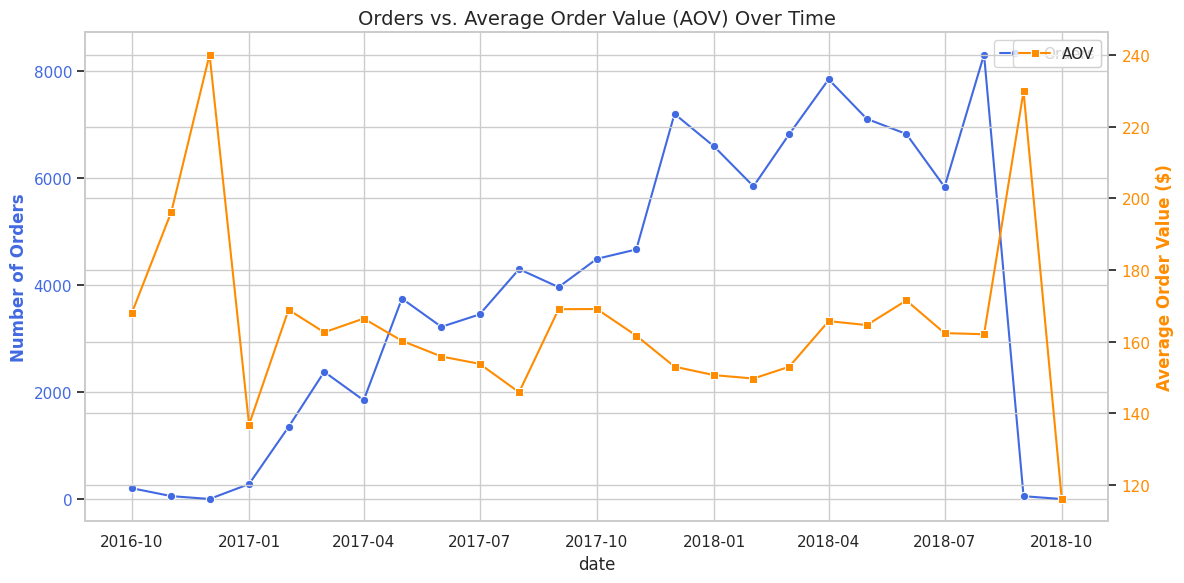

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column to datetime if you haven't already
or_rev_aov_sorted["date"] = pd.to_datetime(or_rev_aov_sorted["date"])

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Orders on the Left Y-Axis
sns.lineplot(
    data=or_rev_aov_sorted,
    x="date",
    y="orders",
    color="royalblue",
    marker="o",
    ax=ax1,
    label="Orders",
)
ax1.set_ylabel("Number of Orders", color="royalblue", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="royalblue")

# Create a second Y-axis for AOV
ax2 = ax1.twinx()
sns.lineplot(
    data=or_rev_aov_sorted, x="date", y="aov", color="darkorange", marker="s", ax=ax2, label="AOV"
)
ax2.set_ylabel("Average Order Value ($)", color="darkorange", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="darkorange")

plt.title("Orders vs. Average Order Value (AOV) Over Time", fontsize=14)
fig.tight_layout()
plt.show()


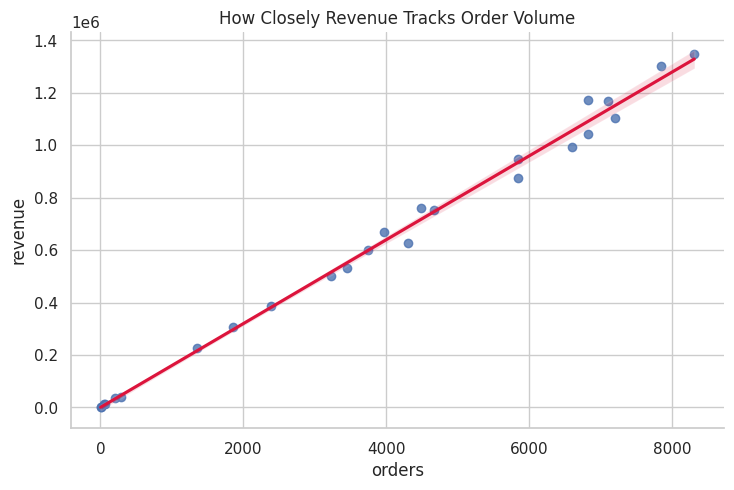

In [88]:
# Check relationship between Orders and Revenue
sns.lmplot(
    data=or_rev_aov_sorted,
    x="orders",
    y="revenue",
    height=5,
    aspect=1.5,
    line_kws={"color": "crimson"},
)
plt.title("How Closely Revenue Tracks Order Volume")
plt.show()


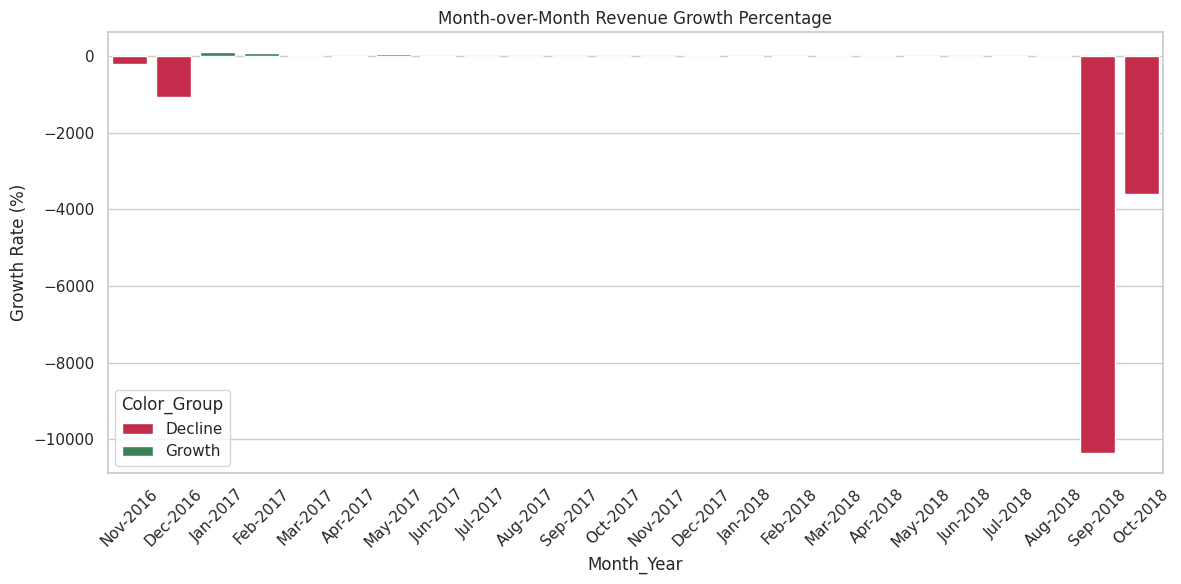

In [89]:
plt.figure(figsize=(12, 6))

# Clean out the initial NaN rows for plotting percentage changes
or_rev_aov_sorted_clean = or_rev_aov_sorted.dropna(subset=["revenue_increase_pct"]).copy()
or_rev_aov_sorted_clean["Month_Year"] = or_rev_aov_sorted_clean["date"].dt.strftime("%b-%Y")

# Create a column to color positive vs negative changes differently
or_rev_aov_sorted_clean["Color_Group"] = or_rev_aov_sorted_clean["revenue_increase_pct"].apply(
    lambda x: "Growth" if x >= 0 else "Decline"
)

sns.barplot(
    data=or_rev_aov_sorted_clean,
    x="Month_Year",
    y="revenue_increase_pct",
    hue="Color_Group",
    palette={"Growth": "seagreen", "Decline": "crimson"},
)

plt.xticks(rotation=45)
plt.title("Month-over-Month Revenue Growth Percentage")
plt.ylabel("Growth Rate (%)")
plt.tight_layout()
plt.show()


```
Q1 — What changed?
Analytical question

How did the marketplace's overall performance change between Jan–Aug 2017 and Jan–Aug 2018?

Calculate for both periods:

Total revenue
Total orders
Unique customers
AOV
Orders per customer

Report:

absolute values
% change
Your output

Create one summary table:

Metric	Jan–Aug 2017	Jan–Aug 2018	% Change
Revenue			
Orders			
Customers			
AOV			
Orders/customer			
Your job

Write 3–4 sentences answering:

What actually changed?

Don't explain why yet.

Q2 — What explains the revenue change?
Analytical question

Was the change in revenue primarily driven by order volume or order value?

Use:

Revenue = Orders × AOV

Compare the change in:

Orders
AOV
Revenue

Then answer:

Which component is the dominant driver of the revenue change?

Required output

A small table + one visualization.

Then write:

Revenue changed by X%, primarily because ______ changed by Y%, while ______ changed by Z%.

Don't just say "orders are higher."

Q3 — Why did order volume change?

Now drill one level deeper.

Analytical question

Did the change in orders come from acquiring more customers or from existing customers placing more orders?

Calculate:

Unique customers
Orders
Orders per customer

for both periods.

Then answer:

Is order growth primarily customer-growth-driven or frequency-driven?

Required reasoning

You should explicitly connect:

Revenue
   ↓
Orders
   ↓
Customers + Orders/customer

Don't segment yet.

Q4 — Where is the change concentrated?

Now you're allowed to segment.

Analytical question

Which product categories contributed most to the change in revenue between Jan–Aug 2017 and Jan–Aug 2018?

Use:

orders → order_items → products → category translation

For each category, calculate:

2017 revenue
2018 revenue
absolute revenue change
% revenue change
share of total revenue change

Then identify:

Top 5 positive contributors

and

Top 5 negative contributors
Important

Don't conclude:

"Category X grew 80%, therefore Category X caused overall growth."

You need to distinguish:

growth rate from contribution to total growth.

That's an important analyst skill.

Q5 — Is the growth healthy?

Now investigate one operational dimension.

Analytical question

Did order fulfillment quality change alongside the business growth?

Use order status and delivery timestamps.

Calculate for Jan–Aug 2017 vs Jan–Aug 2018:

cancellation/unavailable rate
average delivery time
late-delivery rate

You don't need all three if time is tight.

Minimum: cancellation/unavailable rate + late-delivery rate.

For late delivery, define it clearly using:

actual customer delivery date vs estimated delivery date.

Your job

Answer:

Did the business grow without obvious deterioration in fulfillment quality?

This introduces the idea:

Growth ≠ necessarily healthy growth.

Q6 — Final analyst conclusion

Now stop calculating.

Pretend you're sitting in front of management.

Answer:

"So, what happened?"

Your final response must contain exactly these six pieces:

1. What changed?

Revenue increased/decreased X%.

2. Primary driver

The dominant driver was ______.

3. Underlying driver

This was primarily caused by ______.

4. Concentration

The change was particularly concentrated in ______.

5. Business health

Fulfillment/customer quality ______.

6. Recommendation

Management should ______.

And every major statement needs a number behind it.

In [90]:
# Q1 —How did the marketplace's overall performance change between Jan–Aug 2017 and Jan–Aug 2018?

# Calculate for both periods:
# Total revenue
# Total orders
# Unique customers
# AOV
# Orders per customer


In [91]:
or_rev_aov_sorted

,year,month,orders,revenue,aov,date,orders_increase_pct,revenue_increase_pct,aov_increase_pct
0,2016.0,Oct,205,34438.41,167.992244,2016-10-01,NaN,NaN,NaN
1,2016.0,Nov,57,11187.07,196.264386,2016-11-01,-259.649123,-207.841195,14.405131
2,2016.0,Dec,4,960.85,240.212500,2016-12-01,-1325.000000,-1064.288911,18.295515
3,2017.0,Jan,283,38708.63,136.779611,2017-01-01,98.586572,97.517737,-75.620107
4,2017.0,Feb,1351,228152.25,168.876573,2017-02-01,79.052554,83.033860,19.006166
5,2017.0,Mar,2382,387275.32,162.584097,2017-03-01,43.282955,41.087842,-3.870290
6,2017.0,Apr,1849,307722.84,166.426631,2017-04-01,-28.826393,-25.851991,2.308845
7,2017.0,May,3751,600917.76,160.202015,2017-05-01,50.706478,48.791189,-3.885479
8,2017.0,Jun,3223,502197.97,155.816931,2017-06-01,-16.382253,-19.657545,-2.814254
9,2017.0,Jul,3455,531271.71,153.768946,2017-07-01,6.714906,5.472480,-1.331859


In [92]:
or_rev_aov_sorted[((or_rev_aov_sorted.date >= '2017-01-01') & (or_rev_aov_sorted.date < '2017-09-01' )) | ((or_rev_aov_sorted.date >= '2018-01-01') & (or_rev_aov_sorted.date < '2018-09-01' ))]

,year,month,orders,revenue,aov,date,orders_increase_pct,revenue_increase_pct,aov_increase_pct
3,2017.0,Jan,283,38708.63,136.779611,2017-01-01,98.586572,97.517737,-75.620107
4,2017.0,Feb,1351,228152.25,168.876573,2017-02-01,79.052554,83.033860,19.006166
5,2017.0,Mar,2382,387275.32,162.584097,2017-03-01,43.282955,41.087842,-3.870290
6,2017.0,Apr,1849,307722.84,166.426631,2017-04-01,-28.826393,-25.851991,2.308845
7,2017.0,May,3751,600917.76,160.202015,2017-05-01,50.706478,48.791189,-3.885479
8,2017.0,Jun,3223,502197.97,155.816931,2017-06-01,-16.382253,-19.657545,-2.814254
9,2017.0,Jul,3455,531271.71,153.768946,2017-07-01,6.714906,5.472480,-1.331859
10,2017.0,Aug,4302,627367.19,145.831518,2017-08-01,19.688517,15.317263,-5.442876
15,2018.0,Jan,6597,993588.74,150.612209,2018-01-01,-9.216310,-10.934492,-1.573191
16,2018.0,Feb,5850,875514.19,149.660545,2018-02-01,-12.769231,-13.486309,-0.635881
